This is firs assignment (out of three). 

Submission guideline:

- Total point- 100 

- Attend all questions.

- Upload a zip/rar file containing the following:

    - MAS512_assignment1_gr#.py or MAS512_assignment1_gr#.ipynb. These files should be error free.

    - Each questions should be done in a cell, such that when I run the cell - I get the outputs.
    
    - MAS512_assignment1_gr#.ppt explaining the objective, method and results of each questions. 
    
    - Make   the presentation clear, readable, precise and attractive.

- Each group will be given 10 min to present the assignment followed by 5 minutes of Q/A. The presentation takes place in Lab, and all students are expected to attend peer's presentation

- Assignment is graded based on problem solving skills, work break down, algorithms, code, powerpoint and presentation

- Students are expected to solve the problem themselves.

- You can use LLM generative models as 'help', understand the working and algorithm, modify and use them.

- Be specific and precise when you write code, make powerpoint and present assignment

# Q1. Object detection and depth estimation                             20+5+20 = 45 points
 Use L515 camera in Lab to acquire rgb video and depth video (e.g. 30 s) of swinging load in lab (rgb_train_val_swingingload.avi; depth_train_val_swingingload.avi). Extract each frames from rgb video. Use the extracted images to train and validate YOLO model (save as YOLO_swinging_load.pt). Record test_swingingload.avi (e.g. 5 s). Extract frames and use them as test data set. Test your YOLO model (YOLO_swinging_load.pt) on this test data set.

(a) Show the performance of your model on test data set by plotting relevant KPIs.

(b) Sample five random images from test data video (test_swingingload.avi). Find the center, and coordinates of bounding box. Display them on the each test image.

(c) realsense_acq.ipynb contains code that streams, rgb, and depth video. Based on this code, extract the frames from depth_train_val_swingingload.avi. Each pixel in each frame consists of depth information of corresponding rgb images. As described in Q1.b find the center of bounding box of ALL frames in  test video (test_swingingload.avi). Display its center and corresponding depth.


References: Use Ultralytics framework for help - https://docs.ultralytics.com/tasks/detect
Realsense - https://dev.realsenseai.com/sdk-2-0-code-samples-wrappers-and-languages/opencv/ 

# Q2. Object tracking                                                           5 points
  Perform tracking of swinging load on test_swingingload.avi. You should display the trajectory of load as it swings each frame as shown in Fig. below. 

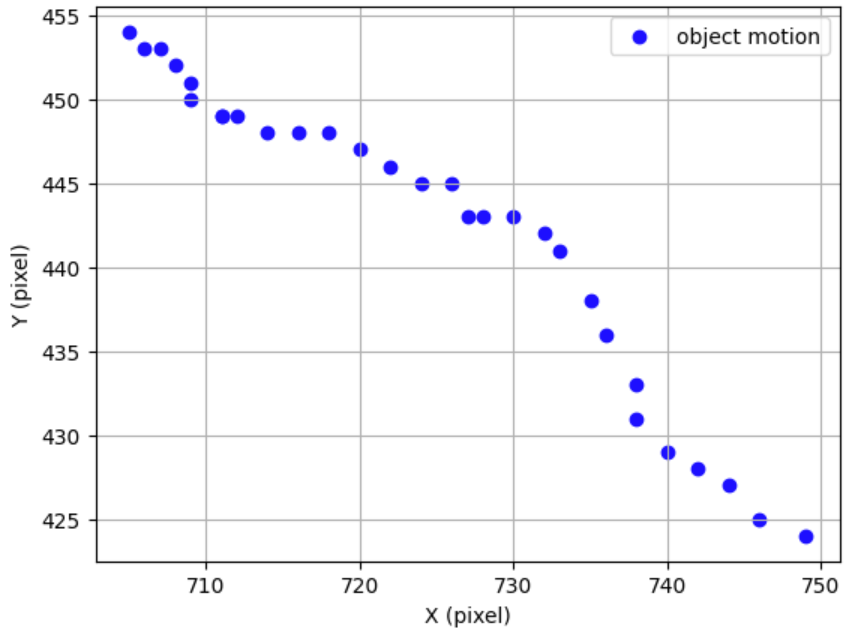

Ref: Use help from Ultralytics - https://docs.ultralytics.com/guides/instance-segmentation-and-tracking 

# Q3. Multi object segmentation, tracking and counting:                         10  points

Explore different data-set available freely on internet (https://docs.ultralytics.com/datasets ). Get familiar with them. Then choose a data set and corresponding class of your choice (e.g. CICAR-10 dataset/COCO data set or KITTI data set / person). Then make a video such that multiple instances of objects are in the scene (e.g. 5 people are the scene). Perform 
(a) instance segmentation, 
(b) counting  - total number of object in scene
(c) and tracking of individual instance of object
(d) draw a region - and count the object in that region


# Q4. Classification                                                        10  marks
Given the data-set fault-classification-class. Perform the following
(a) Develop ML model to determine the state of health of asset (in this case motor).
(b) Show, train and val loss, confusion matrix and classification report
(c) Consider the one in the class as baseline and compare your model with it. Summarize in terms of
model parameter, inference time, accuracy, precision, recall, F1 score

# Q5. Classification                                                        20  
Download CFAR-10 dataset (https://www.tensorflow.org/datasets/catalog/cifar10). Perform the classification task on this dataset 
(a) Use model fusion (use two or models to extract feature and combine them), 
(b) Use transfer learning
(c) Use finetuning
(d) Compare different methods (a) - (c) in terms of typical KPIs often used for classification

# Q6. Autoencoder                                                           10 marks
Given the data-set fault-classification-class, 
Use Auto encoder to compress the data to latent space and reconstruct it back. Show the following for random 10 iamges from each class
(a) Original image
(b) Latent vector
(c) Reconstructed back image
(d) individual reconstruction error and mean loss for each class.


Q1
Detection - Find the object in scene
3D - RGB image

1. Film rgb_train_val_swingingload.avi

2. trekk ut frames: Open CV
https://dev.realsenseai.com/sdk-2-0-code-samples-wrappers-and-languages/opencv/
https://opencv.org/reading-and-writing-videos-using-opencv/#h-import-cv2

3. annoter lasten
4. tren egen YOLO-modell
5. lagre modellen som YOLO_swinging_load.pt
6. kjør den på test_swingingload.avi

In [21]:
from pathlib import Path
from ultralytics import YOLO
import shutil
import yaml

# Main project folder
project_folder = Path.cwd()

# Dataset folders
data_folder = project_folder / "Data"

train_folder = data_folder / "Train"
test_folder = data_folder / "Test"

# RGB data
train_rgb = train_folder / "rgb_frames"
test_rgb = test_folder / "rgb_frames"

# Depth data
test_depth = test_folder / "depth_raw"
depth_scale_file = test_folder / "depth_scale_json" / "depth_scale.json"

# Files used during our YOLO workflow
annotation_file = project_folder / "swingingload30.ndjson"
dataset_yolo = project_folder / "Dataset_YOLO"
selectedtraining_frames = train_folder / "rgb_selected"
trained_model_file = project_folder / "YOLO_swinging_load.pt"

# Count the available RGB frames
number_train_frames = len(list(train_rgb.glob("*.png")))
number_test_frames = len(list(test_rgb.glob("*.png")))

print("Dataset successfully found!")
print("You now have the following RGB frames:")
print("Training RGB frames:", number_train_frames)
print("Testing RGB frames:", number_test_frames)

Dataset successfully found!
You now have the following RGB frames:
Training RGB frames: 900
Testing RGB frames: 300


In [4]:
# Selection of 30 pictures

selectedtraining_frames.mkdir(parents=True, exist_ok=True)

image_files = sorted(train_rgb.glob("*.png"))

# Select 30 evenly distributed frames from the training video. This is important because we want to ensure that the selected frames represent the entire video and not just a specific segment. By selecting frames at regular intervals, we can capture a diverse set of images that cover different parts of the video. This is crucial for training a robust model that can generalize well to new data.
selected_files = image_files[::30]

for image_path in selected_files:
    shutil.copy(
        image_path,
        selectedtraining_frames / image_path.name
    )

print("Selected images:", len(selected_files))

Selected images: 30


In [22]:
from ultralytics.data.converter import convert_ndjson_to_yolo

yaml_path = await convert_ndjson_to_yolo(
    str(annotation_file),
    output_path=str(dataset_yolo)
)

print("YOLO dataset:", yaml_path)

YOLO dataset: c:\Users\hedhe\MAS512_Group9\Dataset_YOLO\swingingload30-3822835c\data.yaml


In [23]:
# Check which classes are included in the converted YOLO dataset
with open(yaml_path) as file:
    dataset_config = yaml.safe_load(file)

print("Classes:", dataset_config["names"])

Classes: {0: 'swinging_load'}


In [24]:
#Transfer Learning: Loading the pretrained ultralytics YOLOv8 model and train it on the selected images

model = YOLO("yolo26n.pt")


In [25]:
# Train the model on the selected and annotated images
# The model is trained for 100 epochs with an image size of 640 pixels

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640
)

New https://pypi.org/project/ultralytics/8.4.161 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.158  Python-3.10.11 torch-2.14.0+cpu CPU (11th Gen Intel Core i7-11370H @ 3.30GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\hedhe\MAS512_Group9\Dataset_YOLO\swingingload30-3822835c\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, ma

KeyboardInterrupt: 

In [ ]:
#To ensure Saving the best model weights after training

best_weights = Path(results.save_dir) / "weights" / "best.pt"

shutil.copy(best_weights, trained_model_file)

trained_model = YOLO(trained_model_file)

print("The saved trained model is:", trained_model_file.name)

The saved trained model is: YOLO_swinging_load.pt


## Q1(a): Model performance on the test data set

`test_swingingload.avi` has no ground-truth boxes (only the 30 training frames were annotated), so
classic precision/recall/mAP can't be computed on it directly. Instead we run the trained model over
every test frame and report practical KPIs: detection confidence, how many frames actually get a
detection, and inference speed.

If you also annotate the test frames later and build a `data.yaml` for them, swap in
`trained_model.val(data=..., split="test")` instead — that gives the standard mAP/PR-curve/
confusion-matrix plots Ultralytics produces during training.


Performance evaluation: Validation performance: Precision, Recall, F1, mAP50, mAP50-95

In [26]:
# Evaluate the trained YOLO model

metrics = trained_model.val(
    data=yaml_path
)

Ultralytics 8.4.158  Python-3.10.11 torch-2.14.0+cpu CPU (11th Gen Intel Core i7-11370H @ 3.30GHz)
YOLO26n summary (fused): 120 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 526.3133.8 MB/s, size: 79.9 KB)
val: Scanning C:\Users\hedhe\MAS512_Group9\Dataset_YOLO\swingingload30-3822835c\labels\val.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.4it/s 0.4s
                   all          6          6       0.99      0.833      0.955       0.79
Speed: 11.3ms preprocess, 42.1ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to C:\Users\hedhe\MAS512_Group9\runs\detect\val-2


In [27]:
# Main YOLO performance metrics

precision = metrics.box.mp
recall = metrics.box.mr
f1_score = metrics.box.f1[0]
map50 = metrics.box.map50
map50_95 = metrics.box.map

print("YOLO model performance:")
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 score:", round(f1_score, 3))
print("mAP50:", round(map50, 3))
print("mAP50-95:", round(map50_95, 3))

YOLO model performance:
Precision: 0.99
Recall: 0.833
F1 score: 0.905
mAP50: 0.955
mAP50-95: 0.79


Performance when running the trained model on the 300 test-video frames: confidence, frames with no detection, latency and FPS.

In [28]:
import time
import numpy as np
import matplotlib.pyplot as plt

#Testing the trained YOLO model on the test images and measuring inference time, confidence values, and detections per frame

test_images = sorted(test_rgb.glob("*.png"))

confidence_values = []
detections_per_frame = []
inference_times = []

for image_path in test_images:

    start_time = time.perf_counter()

    prediction = trained_model.predict(
        source=str(image_path),
        verbose=False
    )[0]

    inference_time = (time.perf_counter() - start_time) * 1000
    inference_times.append(inference_time)

    if prediction.boxes is not None:
        frame_confidence = prediction.boxes.conf.cpu().numpy()
    else:
        frame_confidence = np.array([])

    confidence_values.extend(frame_confidence.tolist())
    detections_per_frame.append(len(frame_confidence))

Test video performance:
Mean confidence: 0.892
Frames that did not get detected: 1 / 300
Mean inference time: 60.1 ms
Approximate FPS: 16.6


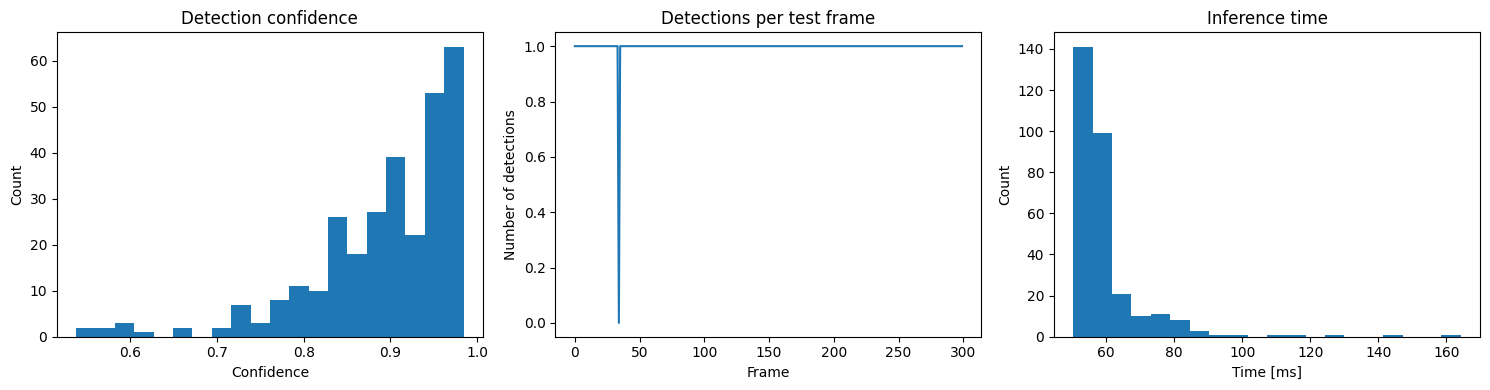

In [29]:
# Calculate test-video performance values

mean_confidence = np.mean(confidence_values)
no_detection_frames = detections_per_frame.count(0)
mean_inference_time = np.mean(inference_times)
fps = 1000 / mean_inference_time

print("Test video performance:")
print("Mean confidence:", round(mean_confidence, 3))
print("Frames that did not get detected:", no_detection_frames, "/", len(test_images))
print("Mean inference time:", round(mean_inference_time, 1), "ms")
print("Approximate FPS:", round(fps, 1))


# Plot the results

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(confidence_values, bins=20)
axes[0].set_title("Detection confidence")
axes[0].set_xlabel("Confidence")
axes[0].set_ylabel("Count")

axes[1].plot(detections_per_frame)
axes[1].set_title("Detections per test frame")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Number of detections")

axes[2].hist(inference_times, bins=20)
axes[2].set_title("Inference time")
axes[2].set_xlabel("Time [ms]")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Q1(b): Bounding box center on 5 random test images


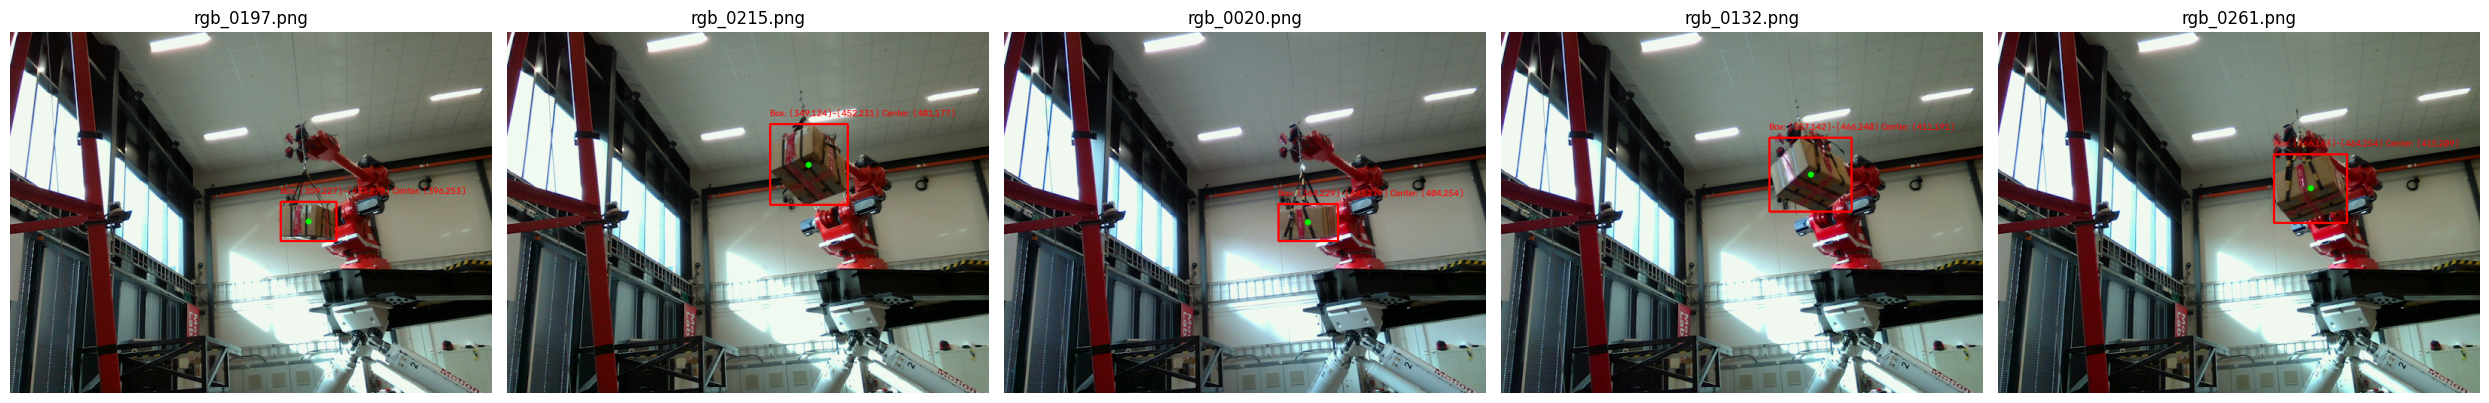

In [30]:
import random
import cv2
import matplotlib.pyplot as plt

random.seed(0)
sample_paths = random.sample(test_images, 5)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, img_path in zip(axes, sample_paths):

    result = trained_model.predict(
        source=str(img_path),
        verbose=False
    )[0]

    img = cv2.cvtColor(
        cv2.imread(str(img_path)),
        cv2.COLOR_BGR2RGB
    )

    for box in result.boxes:

        #Bounding box coordinates for detected object
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        # Calculate center point
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        #Drawing bounding box and center point
        cv2.rectangle(
            img,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (255, 0, 0),
            2
        )

        cv2.circle(
            img,
            (int(cx), int(cy)),
            4,
            (0, 255, 0),
            -1
        )

        # Display bounding box and center coordinates
        label = (
            f"Box: ({x1:.0f},{y1:.0f})-({x2:.0f},{y2:.0f}) "
            f"Center: ({cx:.0f},{cy:.0f})"
        )

        cv2.putText(
            img,
            label,
            (int(x1), max(int(y1) - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.4,
            (255, 0, 0),
            1
        )

    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()


## Q1(c): Depth at the bounding box center for all test frames

Each `rgb_XXXX.png` frame has an index-aligned `depth_XXXX_raw.npy` file (raw uint16 depth, aligned to
the color frame during acquisition — see `realsense_acq.ipynb`). Multiplying the raw value by
`depth_scale` from `depth_scale.json` converts it to meters.


{'frame': '0000', 'center_x': np.float32(397.69168), 'center_y': np.float32(190.76877), 'depth_m': 0.0}
{'frame': '0001', 'center_x': np.float32(417.8469), 'center_y': np.float32(243.76237), 'depth_m': 3.4220001625362784}
{'frame': '0002', 'center_x': np.float32(417.67126), 'center_y': np.float32(247.30887), 'depth_m': 3.5122501668229233}
{'frame': '0003', 'center_x': np.float32(417.72028), 'center_y': np.float32(249.21854), 'depth_m': 3.627750172308879}
{'frame': '0004', 'center_x': np.float32(419.46423), 'center_y': np.float32(251.0777), 'depth_m': 0.0}
Detected in 299 / 300 frames


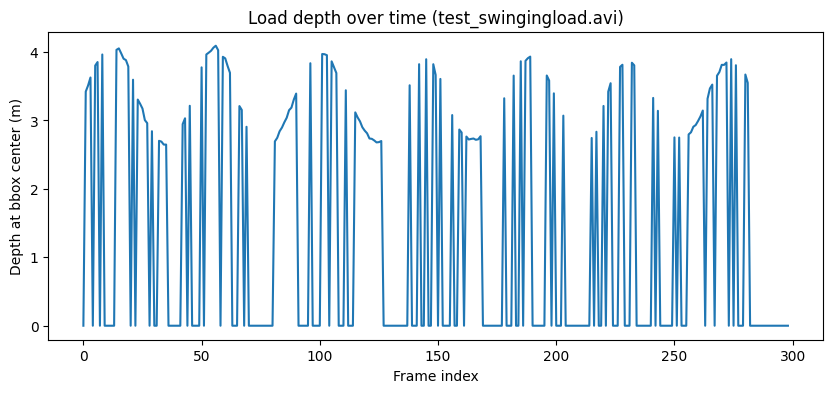

In [31]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open(depth_scale_file) as f:
    depth_scale = json.load(f)["depth_scale"]

records = []

for img_path in test_images:
    frame_idx = img_path.stem.split("_")[-1]  # "rgb_0000" -> "0000"
    depth_path = test_depth / f"depth_{frame_idx}_raw.npy"

    result = trained_model.predict(source=str(img_path), verbose=False)[0]

    if result.boxes is None or len(result.boxes) == 0:
        continue

    # Highest-confidence detection = the load, for frames with multiple detections
    best_idx = int(result.boxes.conf.argmax())

    x1, y1, x2, y2 = result.boxes.xyxy[best_idx].cpu().numpy()
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2

    depth_raw = np.load(depth_path)

    row = min(max(int(round(cy)), 0), depth_raw.shape[0] - 1)
    col = min(max(int(round(cx)), 0), depth_raw.shape[1] - 1)

    depth_m = float(depth_raw[row, col]) * depth_scale

    records.append({
        "frame": frame_idx,
        "center_x": cx,
        "center_y": cy,
        "depth_m": depth_m
    })

for r in records[:5]:
    print(r)

print(f"Detected in {len(records)} / {len(test_images)} frames")

depth_values = [r["depth_m"] for r in records]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(range(len(depth_values)), depth_values)

ax.set_xlabel("Frame index")
ax.set_ylabel("Depth at bbox center (m)")
ax.set_title("Load depth over time (test_swingingload.avi)")

plt.show()


# Q2. Object tracking — trajectory of the swinging load

Runs `trained_model.track(..., persist=True)` frame-by-frame over the test frames (the pattern
Ultralytics recommends for looping over a frame sequence) and plots the bounding-box center of each
frame as a scatter, matching the reference trajectory plot (`Q2_example.png`) from the class materials.


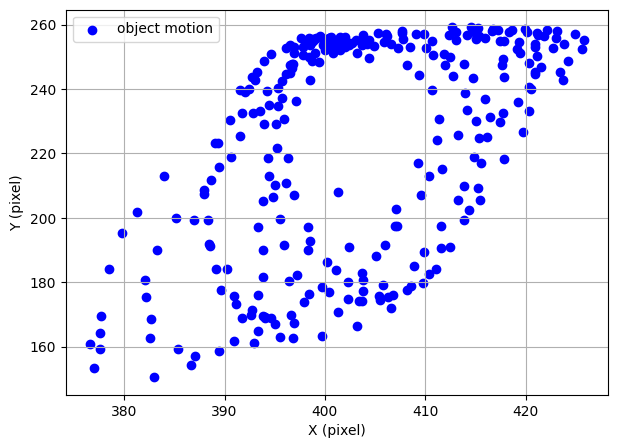

In [32]:
import matplotlib.pyplot as plt

track_xs, track_ys = [], []

for img_path in test_images:
    result = trained_model.track(source=str(img_path), persist=True, verbose=False)[0]
    if result.boxes is None or len(result.boxes) == 0:
        continue
    best_idx = int(result.boxes.conf.argmax())
    x1, y1, x2, y2 = result.boxes.xyxy[best_idx].cpu().numpy()
    track_xs.append((x1 + x2) / 2)
    track_ys.append((y1 + y2) / 2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(track_xs, track_ys, color="blue", label="object motion")
ax.set_xlabel("X (pixel)")
ax.set_ylabel("Y (pixel)")
ax.legend()
ax.grid(True)
plt.show()


# Q4. Classification — motor fault detection

Dataset: `fault-classification-class`, 2 classes (`00_15`, `10_15`), 900 train / 100 test images each,
175x60 spectrogram-style crops. `00_15` sorts first alphabetically so `ImageFolder` assigns it label 0.


In [38]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Looks for the dataset either copied straight into the project folder, or still
# nested inside the class-provided "Assignment 1-class" folder.
FAULT_DATA_CANDIDATES = [
    project_folder / "fault-classification-class",
    project_folder / "Assignment 1-class" / "Assignment 1-class" / "fault-classification-class",
]

FAULT_DATA_ROOT = next(
    (p for p in FAULT_DATA_CANDIDATES if p.exists()),
    None
)

assert FAULT_DATA_ROOT is not None, (
    "Could not find the fault-classification-class dataset. Copy it into the notebook's "
    "folder (or keep the 'Assignment 1-class' folder layout) and re-run."
)

FAULT_TRAIN_DIR = FAULT_DATA_ROOT / "training"
FAULT_TEST_DIR = FAULT_DATA_ROOT / "testing"

print("Fault dataset:", FAULT_DATA_ROOT)

torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.ToTensor()
])

full_train_ds = datasets.ImageFolder(
    FAULT_TRAIN_DIR,
    transform=transform
)

test_ds = datasets.ImageFolder(
    FAULT_TEST_DIR,
    transform=transform
)

print("Classes:", full_train_ds.classes)

n_val = int(0.2 * len(full_train_ds))
n_train = len(full_train_ds) - n_val

train_ds, val_ds = random_split(
    full_train_ds,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(0)
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

print(
    f"Train: {len(train_ds)}, "
    f"Val: {len(val_ds)}, "
    f"Test: {len(test_ds)}"
)

AssertionError: Could not find the fault-classification-class dataset. Copy it into the notebook's folder (or keep the 'Assignment 1-class' folder layout) and re-run.

In [ ]:
class FaultCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_running += loss.item() * x.size(0)
        val_loss = val_running / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    return history


fault_model = FaultCNN(n_classes=len(full_train_ds.classes))
history = train_model(fault_model, train_loader, val_loader, epochs=15)


Epoch 1/15  train_loss=0.4407  val_loss=0.0793
Epoch 2/15  train_loss=0.0248  val_loss=0.0085
Epoch 3/15  train_loss=0.0102  val_loss=0.0078
Epoch 4/15  train_loss=0.0058  val_loss=0.0049
Epoch 5/15  train_loss=0.0039  val_loss=0.0021
Epoch 6/15  train_loss=0.0058  val_loss=0.0019
Epoch 7/15  train_loss=0.0041  val_loss=0.0016
Epoch 8/15  train_loss=0.0050  val_loss=0.0041
Epoch 9/15  train_loss=0.0036  val_loss=0.0013
Epoch 10/15  train_loss=0.0049  val_loss=0.0003
Epoch 11/15  train_loss=0.0007  val_loss=0.0022
Epoch 12/15  train_loss=0.0012  val_loss=0.0003
Epoch 13/15  train_loss=0.0008  val_loss=0.0003
Epoch 14/15  train_loss=0.0005  val_loss=0.0014
Epoch 15/15  train_loss=0.0010  val_loss=0.0004


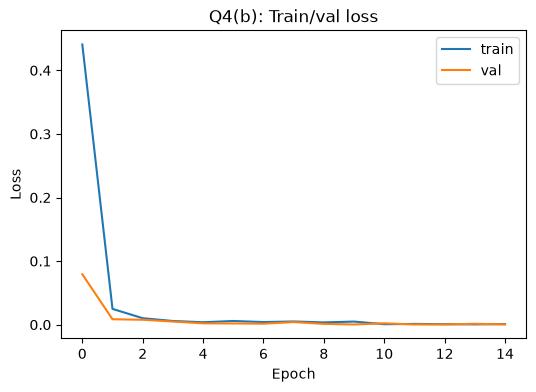

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Q4(b): Train/val loss")
plt.legend()
plt.show()


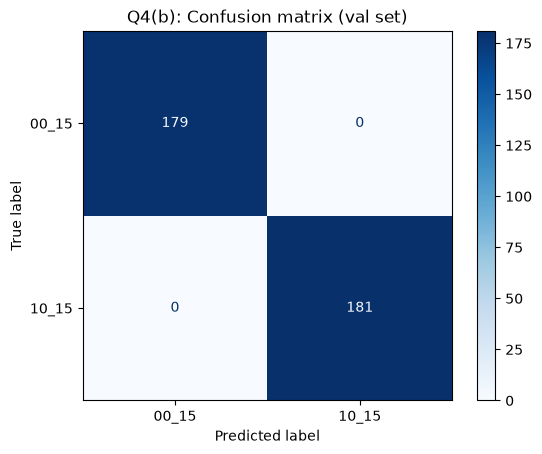

              precision    recall  f1-score   support

       00_15       1.00      1.00      1.00       179
       10_15       1.00      1.00      1.00       181

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = evaluate(fault_model, val_loader)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=full_train_ds.classes).plot(cmap="Blues")
plt.title("Q4(b): Confusion matrix (val set)")
plt.show()

print(classification_report(y_true, y_pred, target_names=full_train_ds.classes))


## Q4(c): Baseline comparison

The actual course baseline (`fault-classification-class.ipynb`, from the class materials) is a Keras
CNN: 4 Conv2D+MaxPool blocks (4→8→8→16 filters), BatchNorm, then a Dense stack
(16→16→2→64→64) with L2 activity regularization and 0.2 dropout, trained with Adam (lr=1e-4)
for 15 epochs at batch size 8. **TensorFlow has no installable wheel for this machine's Python 3.14
yet** (checked directly — PyPI has no matching distribution at all), so that exact architecture and
hyperparameters are reproduced below in PyTorch instead of literally running the Keras notebook.


In [ ]:
import time
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


class BaselineFaultCNN(nn.Module):
    """PyTorch port of the instructor's Keras baseline (fault-classification-class.ipynb):
    same 4 conv blocks, same Dense(16-16-2-64-64) stack with L2 activity regularization on the
    16/16/64/64 layers, same 0.2 dropout before the final softmax."""

    def __init__(self, img_shape, n_classes=2):
        super().__init__()
        c, h, w = img_shape
        self.conv = nn.Sequential(
            nn.Conv2d(c, 4, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(4, 8, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 8, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.BatchNorm2d(16),
        )
        with torch.no_grad():
            flat_dim = self.conv(torch.zeros(1, c, h, w)).flatten(1).shape[1]

        self.fc1 = nn.Linear(flat_dim, 16)
        self.fc2 = nn.Linear(16, 16)
        self.bottleneck = nn.Linear(16, 2)
        self.fc3 = nn.Linear(2, 64)
        self.fc4 = nn.Linear(64, 64)
        self.dropout = nn.Dropout(0.2)
        self.out = nn.Linear(64, n_classes)
        self.relu = nn.ReLU()

    def forward(self, x, return_activity=False):
        x = self.conv(x).flatten(1)
        a1 = self.relu(self.fc1(x))
        a2 = self.relu(self.fc2(a1))
        a3 = self.relu(self.bottleneck(a2))
        a4 = self.relu(self.fc3(a3))
        a5 = self.relu(self.fc4(a4))
        logits = self.out(self.dropout(a5))
        if return_activity:
            return logits, [a1, a2, a4, a5]
        return logits


def train_baseline(model, train_loader, val_loader, epochs=15, lr=1e-4, l2_coef=0.01):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, acts = model(x, return_activity=True)
            loss = criterion(logits, y)
            for a in acts:
                loss = loss + l2_coef * (a ** 2).sum(dim=1).mean()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits, acts = model(x, return_activity=True)
                loss = criterion(logits, y)
                for a in acts:
                    loss = loss + l2_coef * (a ** 2).sum(dim=1).mean()
                val_running += loss.item() * x.size(0)
        val_loss = val_running / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

    return history


sample_x, _ = next(iter(train_loader))

baseline_model = BaselineFaultCNN(img_shape=tuple(sample_x.shape[1:]), n_classes=len(full_train_ds.classes))
baseline_history = train_baseline(baseline_model, train_loader, val_loader, epochs=15, lr=1e-4)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def measure_inference_time(model, loader, n_batches=5):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            if i >= n_batches:
                break
            x = x.to(device)
            t0 = time.perf_counter()
            model(x)
            times.append((time.perf_counter() - t0) * 1000 / x.size(0))
    return np.mean(times)


def summarize(name, model):
    y_true, y_pred = evaluate(model, test_loader)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    return {
        "model": name,
        "params": count_params(model),
        "inference_ms_per_image": measure_inference_time(model, test_loader),
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }


comparison = [
    summarize("Class baseline (Keras CNN, ported to PyTorch)", baseline_model),
    summarize("CNN (this notebook)", fault_model),
]

header = f"{'model':<45}{'params':>10}{'inference_ms':>14}{'accuracy':>10}{'precision':>11}{'recall':>9}{'f1':>8}"
print(header)
for row in comparison:
    print(
        f"{row['model']:<45}{row['params']:>10}{row['inference_ms_per_image']:>14.3f}"
        f"{row['accuracy']:>10.3f}{row['precision']:>11.3f}{row['recall']:>9.3f}{row['f1']:>8.3f}"
    )


# Q6. Autoencoder on fault-classification-class

Convolutional autoencoder trained unsupervised on both classes together (`train_loader` from Q4, labels
ignored). The decoder output is resized back to the exact input size with `F.interpolate`, so the
architecture doesn't depend on getting the 175x60 stride/padding math to line up exactly.


Epoch 1/20  loss=0.06185
Epoch 2/20  loss=0.01878
Epoch 3/20  loss=0.00633
Epoch 4/20  loss=0.00462
Epoch 5/20  loss=0.00397
Epoch 6/20  loss=0.00357
Epoch 7/20  loss=0.00325
Epoch 8/20  loss=0.00288
Epoch 9/20  loss=0.00240
Epoch 10/20  loss=0.00211
Epoch 11/20  loss=0.00188
Epoch 12/20  loss=0.00168
Epoch 13/20  loss=0.00151
Epoch 14/20  loss=0.00142
Epoch 15/20  loss=0.00126
Epoch 16/20  loss=0.00117
Epoch 17/20  loss=0.00111
Epoch 18/20  loss=0.00120
Epoch 19/20  loss=0.00104
Epoch 20/20  loss=0.00099


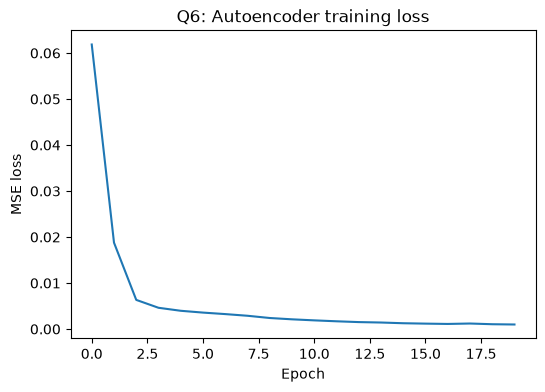

In [ ]:
import torch.nn.functional as F


class ConvAutoencoder(nn.Module):
    def __init__(self, img_shape, latent_dim=32):
        super().__init__()
        c, h, w = img_shape
        self.img_hw = (h, w)

        self.encoder_conv = nn.Sequential(
            nn.Conv2d(c, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, c, h, w)
            enc_out = self.encoder_conv(dummy)
        self.enc_shape = enc_out.shape[1:]
        flat_dim = int(np.prod(self.enc_shape))

        self.to_latent = nn.Linear(flat_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, flat_dim)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, c, 3, stride=2, padding=1, output_padding=1), nn.Sigmoid(),
        )

    def encode(self, x):
        x = self.encoder_conv(x)
        x = x.flatten(1)
        return self.to_latent(x)

    def decode(self, z):
        x = self.from_latent(z)
        x = x.view(-1, *self.enc_shape)
        x = self.decoder_conv(x)
        return F.interpolate(x, size=self.img_hw, mode="bilinear", align_corners=False)

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z


def train_autoencoder(model, loader, epochs=20, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for x, _ in loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, _ = model(x)
            loss = criterion(recon, x)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        epoch_loss = running / len(loader.dataset)
        losses.append(epoch_loss)
        print(f"Epoch {epoch+1}/{epochs}  loss={epoch_loss:.5f}")
    return losses


ae_model = ConvAutoencoder(img_shape=tuple(sample_x.shape[1:]), latent_dim=32)
ae_losses = train_autoencoder(ae_model, train_loader, epochs=20)

plt.figure(figsize=(6, 4))
plt.plot(ae_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Q6: Autoencoder training loss")
plt.show()


In [ ]:
import random
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

ae_model.eval()

class_indices = {cls: [] for cls in test_ds.classes}
for idx, (_, label) in enumerate(test_ds.samples):
    class_indices[test_ds.classes[label]].append(idx)

random.seed(0)
all_errors = {}

for cls_name, indices in class_indices.items():
    sample_idx = random.sample(indices, 10)
    imgs = torch.stack([test_ds[i][0] for i in sample_idx]).to(device)

    with torch.no_grad():
        recon, latent = ae_model(imgs)

    imgs_np = imgs.cpu().numpy()
    recon_np = recon.cpu().numpy().clip(0, 1)

    mse = ((recon_np - imgs_np) ** 2).mean(axis=(1, 2, 3))
    mae = np.abs(recon_np - imgs_np).mean(axis=(1, 2, 3))
    ssim_vals = np.array([
        ssim_metric(
            imgs_np[j].transpose(1, 2, 0), recon_np[j].transpose(1, 2, 0),
            channel_axis=2, data_range=1.0,
        )
        for j in range(imgs_np.shape[0])
    ])
    psnr_vals = np.array([
        psnr_metric(imgs_np[j], recon_np[j], data_range=1.0)
        for j in range(imgs_np.shape[0])
    ])

    all_errors[cls_name] = {"mse": mse, "mae": mae, "ssim": ssim_vals, "psnr": psnr_vals}

    fig, axes = plt.subplots(3, 10, figsize=(20, 6))
    for j in range(10):
        orig = imgs_np[j].transpose(1, 2, 0)
        rec = recon_np[j].transpose(1, 2, 0)
        z = latent[j].cpu().numpy()

        axes[0, j].imshow(orig)
        axes[0, j].axis("off")
        axes[1, j].bar(range(len(z)), z)
        axes[1, j].set_xticks([])
        axes[2, j].imshow(rec)
        axes[2, j].axis("off")
        axes[2, j].set_title(f"mse={mse[j]:.4f}", fontsize=8)

    axes[0, 0].set_ylabel("Original", fontsize=10)
    axes[1, 0].set_ylabel("Latent", fontsize=10)
    axes[2, 0].set_ylabel("Reconstructed", fontsize=10)
    fig.suptitle(f"Q6: class '{cls_name}'")
    plt.tight_layout()
    plt.show()

    print(
        f"Class '{cls_name}': mean MSE={mse.mean():.5f}  MAE={mae.mean():.5f}  "
        f"SSIM={ssim_vals.mean():.4f}  PSNR={psnr_vals.mean():.2f} dB"
    )


In [ ]:
metrics_names = ["mse", "mae", "ssim", "psnr"]
mean_table = {cls: {m: float(np.mean(vals[m])) for m in metrics_names} for cls, vals in all_errors.items()}
for cls, row in mean_table.items():
    print(cls, row)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, m in zip(axes, metrics_names):
    values = [mean_table[cls][m] for cls in mean_table]
    ax.bar(mean_table.keys(), values, color=["steelblue", "darkorange"])
    ax.set_title(m.upper())
plt.suptitle("Q6(d): Mean reconstruction metrics per class")
plt.tight_layout()
plt.show()
